In [4]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100%|██████████████████████████████████████| 3.75G/3.75G [01:32<00:00, 43.4MB/s]



In [5]:

import zipfile

with zipfile.ZipFile("140k-real-and-fake-faces.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset/")

In [6]:
train_dir = "dataset/real_vs_fake/real-vs-fake/train/"
val_dir = "dataset/real_vs_fake/real-vs-fake/valid/"
test_dir= "dataset/real_vs_fake/real-vs-fake/test/"

In [7]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [8]:
# =========================
# 3. DATA PREPROCESSING + AUGMENTATION
# =========================

from tensorflow.keras.applications.efficientnet import preprocess_input

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',

)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',

)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

Found 100000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [10]:
print(train_data.class_indices)

{'fake': 0, 'real': 1}


In [7]:
# =========================
# 4. MODEL BUILDING (TRANSFER LEARNING)
# =========================
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1775305196.466225      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [8]:
# =========================
# 5. CALLBACKS
# =========================
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("deepfake_model.keras", save_best_only=True)
]

In [9]:
# =========================
# 6. TRAINING
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1775305210.970910     149 service.cc:152] XLA service 0x7d64081155b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775305210.970970     149 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775305213.454272     149 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775305225.178467     149 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1141s 179ms/step - accuracy: 0.6360 - loss: 0.6841 - val_accuracy: 0.7954 - val_loss: 0.4459
Epoch 2/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1095s 175ms/step - accuracy: 0.7413 - loss: 0.5294 - val_accuracy: 0.8213 - val_loss: 0.3988
Epoch 3/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1136s 182ms/step - accuracy: 0.7653 - loss: 0.4907 - val_accuracy: 0.8388 - val_loss: 0.3733
Epoch 4/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1138s 182ms/step - accuracy: 0.7821 - loss: 0.4595 - val_accuracy: 0.8475 - val_loss: 0.3579
Epoch 5/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1115s 178ms/step - accuracy: 0.7910 - loss: 0.4467 - val_accuracy: 0.8508 - val_loss: 0.3501
Epoch 6/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1136s 182ms/step - accuracy: 0.8007 - loss: 0.4323 - val_accuracy: 0.8567 - val_loss: 0.3378
Epoch 7/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1174s 188ms/step - accuracy: 0.8072 - loss: 0.4185 - val_accuracy: 0.8615 - val_loss: 0.3300
Epoch 8/15
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1164s 186ms/step - accur

In [10]:
# Unfreeze last few layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5


2026-04-04 17:08:06.566417: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 17:08:06.771468: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 17:08:07.203774: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-04 17:08:07.408807: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1300s 203ms/step - accuracy: 0.7819 - loss: 0.4707 - val_accuracy: 0.8845 - val_loss: 0.2696
Epoch 2/5
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1201s 192ms/step - accuracy: 0.8578 - loss: 0.3281 - val_accuracy: 0.9247 - val_loss: 0.1925
Epoch 3/5
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1252s 200ms/step - accuracy: 0.8808 - loss: 0.2795 - val_accuracy: 0.9244 - val_loss: 0.1860
Epoch 4/5
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1216s 195ms/step - accuracy: 0.8969 - loss: 0.2456 - val_accuracy: 0.9414 - val_loss: 0.1490
Epoch 5/5
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1223s 196ms/step - accuracy: 0.9096 - loss: 0.2177 - val_accuracy: 0.9409 - val_loss: 0.1498


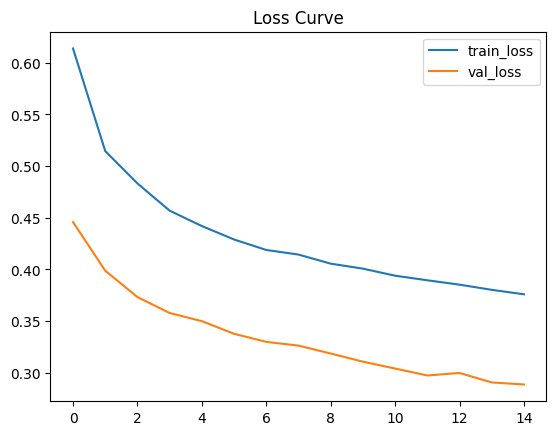

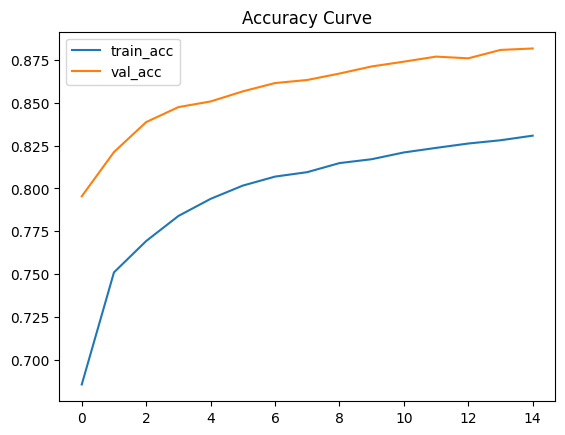

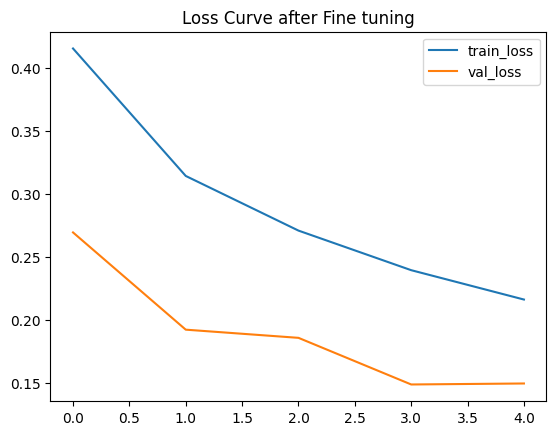

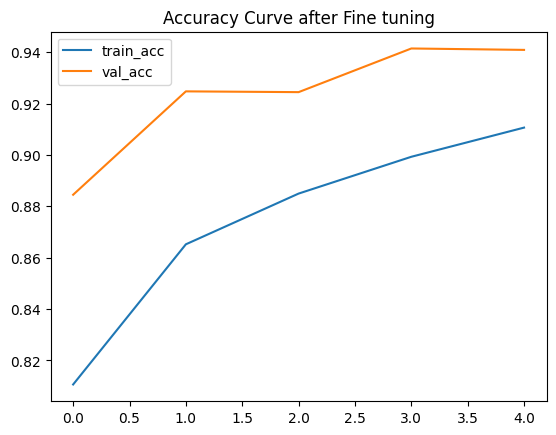

In [11]:
# =========================
# 7. PLOTS (LOSS + ACCURACY)
# =========================
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.figure()
plt.plot(history_fine.history['loss'], label='train_loss')
plt.plot(history_fine.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve after Fine tuning")
plt.show()

plt.figure()
plt.plot(history_fine.history['accuracy'], label='train_acc')
plt.plot(history_fine.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Curve after Fine tuning")
plt.show()


In [12]:
# =========================
# 8. EVALUATION
# =========================
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

# Predictions
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = test_data.classes


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.9110 - loss: 0.2197
Test Accuracy: 0.9401500225067139
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step


In [13]:
# =========================
# 9. METRICS
# =========================
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

print("\nROC-AUC Score:\n")
print(roc_auc_score(y_true, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     10000
           1       0.91      0.98      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000


Confusion Matrix:

[[8997 1003]
 [ 194 9806]]

ROC-AUC Score:

0.9401499999999999


In [3]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# model load karo
model = load_model("/kaggle/input/models/shivaligupta17/deepfakemodel/keras/default/1/deepfake_model.keras")

# image path
img_path = '/kaggle/input/datasets/shivaligupta17/zkjaxaulajl/Gemini_Generated_Image_czq8xwczq8xwczq8.png'   # yaha apni image ka path do

# image load aur preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# expand dims (model ke liye)
img_array = np.expand_dims(img_array, axis=0)

# preprocess (IMPORTANT)
img_array = preprocess_input(img_array)

# prediction
prediction = model.predict(img_array)[0][0]

# result
if prediction > 0.5:
    confidence = prediction * 100
    print(f"Real ✅ with {confidence:.2f}% confidence")
else:
    confidence = (1 - prediction) * 100
    print(f"Fake ❌ with {confidence:.2f}% confidence")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Real ✅ with 99.69% confidence


In [28]:
import os
from IPython.display import FileLink

save_path = "/kaggle/working/deepfake_model.keras"
model.save(save_path)

print("Files:", os.listdir("/kaggle/working"))

FileLink(save_path)

Files: ['.virtual_documents', 'dataset', 'deepfake_model.keras', 'download_deepfake_model.keras', '140k-real-and-fake-faces.zip']


/kaggle/working/deepfake_model.keras

In [27]:
model.save("deepfake_model.keras")

In [19]:
model.save("/kaggle/working/deepfake_model.keras")

In [24]:
import shutil
shutil.copy("/kaggle/working/deepfake_model.pth", "/kaggle/working/download_deepfake_model.pth")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/deepfake_model.pth'

In [22]:
from tensorflow.keras.models import load_model
model = load_model("deepfake_model.keras")

In [14]:
import os
os.listdir('/kaggle/working')

['.virtual_documents',
 'deepfake_modal.keras',
 'dataset',
 '140k-real-and-fake-faces.zip']

In [11]:
model.save("/kaggle/working/deepfake_modal.keras")

In [32]:
# save
model.save("/kaggle/working/deepfake_model.keras")

# check
import os
print(os.listdir('/kaggle/working'))

# download link
from IPython.display import FileLink
FileLink('/kaggle/working/deepfake_model.keras')


['deepfake_modal.keras', '.virtual_documents', 'dataset', 'deepfake_model.keras', 'download_deepfake_model.keras', '140k-real-and-fake-faces.zip']


/kaggle/working/deepfake_model.keras

In [2]:
# =========================
# 1. IMPORTS
# =========================
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# =========================
# 3. DATA GENERATORS
# =========================
# Using same preprocessing as your original notebook (EfficientNet preprocess_input)

train_dir = "/kaggle/input/datasets/shivaligupta17/finetunedataset/new dataset/train"
val_dir   = "/kaggle/input/datasets/shivaligupta17/finetunedataset/new dataset/valid"

# Aggressive augmentation for small dataset
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    shear_range=0.1
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Smaller batch size for small dataset
BATCH_SIZE = 8

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_data.class_indices)

Found 202 images belonging to 2 classes.
Found 41 images belonging to 2 classes.
Class indices: {'fake': 0, 'real': 1}


In [3]:
# =========================
# 4. LOAD YOUR PRETRAINED MODEL
# =========================
MODEL_PATH = "/kaggle/input/models/shivaligupta17/deepfakemodel/keras/default/1/deepfake_model.keras"   # <-- path to your saved model

model = load_model(MODEL_PATH)
print("Model loaded ✅")
model.summary()

I0000 00:00:1780221257.978299      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model loaded ✅


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,044,392 (19.24 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 661,508 (2.52 MB)

In [10]:
# =========================
# 5. HANDLE CLASS IMBALANCE
# =========================
# If you only have fake images and few/no real images,
# class weights help prevent the model from being biased.

n_fake  = len(os.listdir("/kaggle/input/datasets/shivaligupta17/finetunedataset/new dataset/train/fake"))
n_real  = len(os.listdir("/kaggle/input/datasets/shivaligupta17/finetunedataset/new dataset/train/real"))
total   = n_fake + n_real

print(f"Train | fake: {n_fake} | real: {n_real}")

if n_real > 0:
    class_weight = {
        0: total / (2 * n_fake),   # class 0 = fake (check class_indices above)
        1: total / (2 * n_real),   # class 1 = real
    }
else:
    class_weight = None  # Only fake images; no weighting needed

print("Class weights:", class_weight)

Train | fake: 100 | real: 102
Class weights: {0: 1.01, 1: 0.9901960784313726}


In [11]:
# =========================
# 6. FREEZE ALL LAYERS EXCEPT THE HEAD
# (Phase 1: Only train the custom Dense layers)
# =========================
for layer in model.layers:
    layer.trainable = False

# Unfreeze only the top dense layers (last 4 layers)
for layer in model.layers[-4:]:
    layer.trainable = True

# Use a LOWER learning rate to avoid overwriting pretrained weights
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Trainable layers:")
for layer in model.layers:
    if layer.trainable:
        print(" -", layer.name)

Trainable layers:
 - batch_normalization
 - dense
 - dropout
 - dense_1


In [12]:
# =========================
# 7. CALLBACKS
# =========================
callbacks = [
    EarlyStopping(patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint("deepfake_finetuned.keras", save_best_only=True, verbose=1)
]

In [13]:
# =========================
# 8. PHASE 1 TRAINING (Head only)
# =========================
print("=== Phase 1: Training head only ===")

history_phase1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weight
)

=== Phase 1: Training head only ===
Epoch 1/10


I0000 00:00:1780221410.970913     155 service.cc:152] XLA service 0x7ecab0001810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780221410.970956     155 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780221413.216269     155 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780221423.725388     155 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.3533 - loss: 1.4635
Epoch 1: val_loss improved from None to 1.33924, saving model to deepfake_finetuned.keras

Epoch 1: finished saving model to deepfake_finetuned.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.3465 - loss: 1.4351 - val_accuracy: 0.3171 - val_loss: 1.3392
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.4533 - loss: 1.0058
Epoch 2: val_loss improved from 1.33924 to 0.81214, saving model to deepfake_finetuned.keras

Epoch 2: finished saving model to deepfake_finetuned.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 498ms/step - accuracy: 0.5347 - loss: 0.9024 - val_accuracy: 0.5854 - val_loss: 0.8121
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.6823 - loss: 0.6760
Epoch 3: val_loss improved from 0.81214 to 0.55013, saving model to deepfake_finetuned.keras

Epoch 3: finished saving model to deepfake_finetuned.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 494ms/step - accuracy: 0.6980 - l

In [17]:
# =========================
# Phase 2: Fine-tuning last 30 EfficientNet layers (FIXED v3)
# =========================
# Your model is FLAT (242 layers, no nested sub-model)
# EfficientNet layers are [0] to [237], custom head is [238] to [242]
# We unfreeze the last 30 EfficientNet layers: indices [208] to [237]

# First freeze everything
for layer in model.layers:
    layer.trainable = False

# Unfreeze last 30 layers of EfficientNet body (before the custom head)
EFFICIENTNET_END = 238   # global_average_pooling2d starts here (custom head)
for layer in model.layers[EFFICIENTNET_END - 30 : EFFICIENTNET_END]:
    layer.trainable = True

# Always keep the custom head trainable
for layer in model.layers[EFFICIENTNET_END:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Confirm what's trainable
print("Trainable layers:")
for i, layer in enumerate(model.layers):
    if layer.trainable:
        print(f"  [{i}] {layer.name}")

Trainable layers:
  [208] block6d_expand_bn
  [209] block6d_expand_activation
  [210] block6d_dwconv
  [211] block6d_bn
  [212] block6d_activation
  [213] block6d_se_squeeze
  [214] block6d_se_reshape
  [215] block6d_se_reduce
  [216] block6d_se_expand
  [217] block6d_se_excite
  [218] block6d_project_conv
  [219] block6d_project_bn
  [220] block6d_drop
  [221] block6d_add
  [222] block7a_expand_conv
  [223] block7a_expand_bn
  [224] block7a_expand_activation
  [225] block7a_dwconv
  [226] block7a_bn
  [227] block7a_activation
  [228] block7a_se_squeeze
  [229] block7a_se_reshape
  [230] block7a_se_reduce
  [231] block7a_se_expand
  [232] block7a_se_excite
  [233] block7a_project_conv
  [234] block7a_project_bn
  [235] top_conv
  [236] top_bn
  [237] top_activation
  [238] global_average_pooling2d
  [239] batch_normalization
  [240] dense
  [241] dropout
  [242] dense_1


In [18]:
callbacks_p2 = [
    EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint("deepfake_finetuned.keras", save_best_only=True, verbose=1)
]

history_phase2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks_p2,
    class_weight=class_weight
)

Epoch 1/5


2026-05-31 10:09:59.796271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 10:10:00.001502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


12/26 ━━━━━━━━━━━━━━━━━━━━ 5s 379ms/step - accuracy: 0.8649 - loss: 0.3879

2026-05-31 10:10:17.013477: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-31 10:10:17.218499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 827ms/step - accuracy: 0.8373 - loss: 0.3932
Epoch 1: val_loss improved from None to 0.15262, saving model to deepfake_finetuned.keras

Epoch 1: finished saving model to deepfake_finetuned.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8020 - loss: 0.4146 - val_accuracy: 0.9268 - val_loss: 0.1526
Epoch 2/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.7813 - loss: 0.4437
Epoch 2: val_loss improved from 0.15262 to 0.15095, saving model to deepfake_finetuned.keras

Epoch 2: finished saving model to deepfake_finetuned.keras
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 497ms/step - accuracy: 0.8218 - loss: 0.3819 - val_accuracy: 0.9268 - val_loss: 0.1509
Epoch 3/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8706 - loss: 0.3551
Epoch 3: val_loss did not improve from 0.15095
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 461ms/step - accuracy: 0.8267 - loss: 0.4029 - val_accuracy: 0.9268 - val_loss: 0.1549
Epoch 4/5
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - a

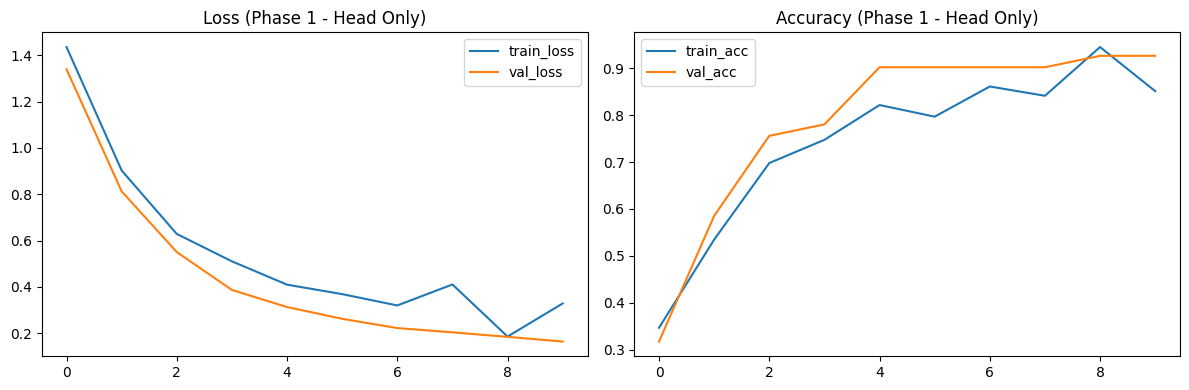

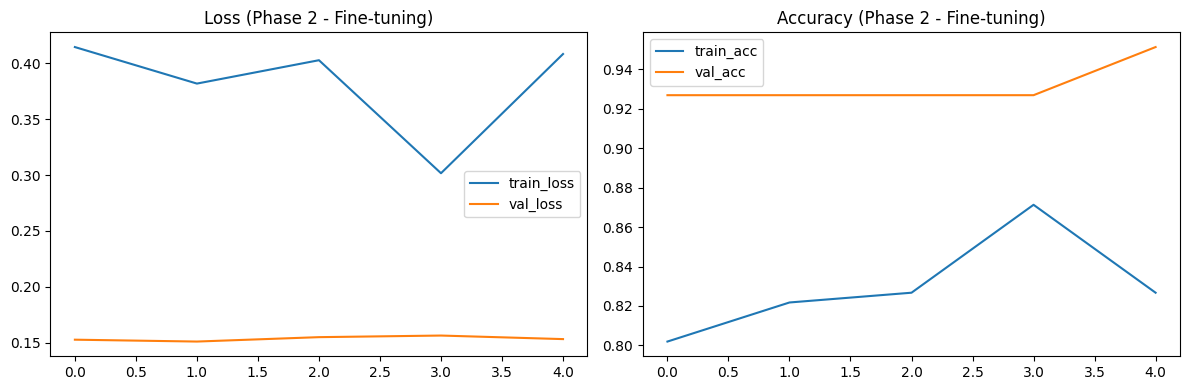

In [19]:
# =========================
# 10. PLOT TRAINING CURVES
# =========================
def plot_history(history, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'], label='train_loss')
    axes[0].plot(history.history['val_loss'], label='val_loss')
    axes[0].legend()
    axes[0].set_title(f"Loss {title_suffix}")

    axes[1].plot(history.history['accuracy'], label='train_acc')
    axes[1].plot(history.history['val_accuracy'], label='val_acc')
    axes[1].legend()
    axes[1].set_title(f"Accuracy {title_suffix}")

    plt.tight_layout()
    plt.show()

plot_history(history_phase1, "(Phase 1 - Head Only)")
plot_history(history_phase2, "(Phase 2 - Fine-tuning)")

In [6]:
# =========================
# 11. PREDICT ON A SINGLE IMAGE
# Same style as your original notebook
# =========================
from tensorflow.keras.preprocessing import image as keras_image

model = load_model("deepfake_finetuned.keras")

img_path ="D:\Downloads\4.jpg"   # <-- change to your image path

img = keras_image.load_img(img_path, target_size=(224, 224))
img_array = keras_image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)[0][0]

if prediction > 0.5:
    confidence = prediction * 100
    print(f"Real ✅ with {confidence:.2f}% confidence")
else:
    confidence = (1 - prediction) * 100
    print(f"Fake ❌ with {confidence:.2f}% confidence")

OSError: [Errno 22] Invalid argument: 'D:\\Downloads\x04.jpg'

In [28]:
# =========================
# 12. SAVE FINAL MODEL
# =========================
model.save("deepfake_finetuned_final.keras")
print("Saved ✅ → deepfake_finetuned_final.keras")

import os
print("Files:", os.listdir("."))

Saved ✅ → deepfake_finetuned_final.keras
Files: ['.virtual_documents', 'deepfake_finetuned_final.keras', 'deepfake_finetuned.keras']


In [29]:
model.save("/kaggle/working/deepfake_finetuned_final.keras")